RL and LLMs<br>
Python Note: Policy-based RL (REINFORCE)<br>

We will use CartPole example in OpenAI gymnasium to illustrate the policy-based RL methods.

https://gymnasium.farama.org/environments/classic_control/



In [1]:
pip install gymnasium torch numpy matplotlib

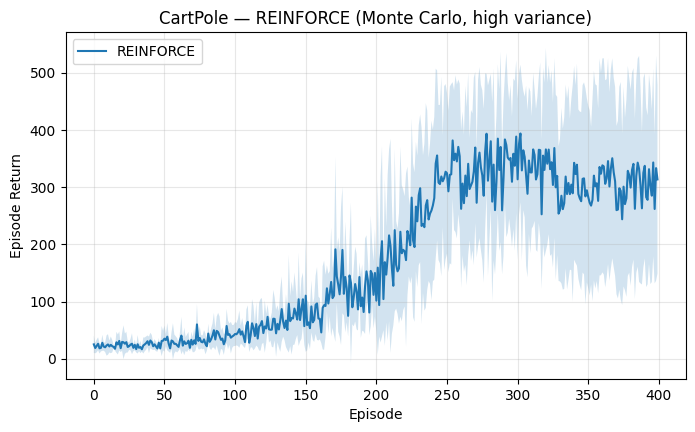

Early policy (ep 10) survived 27 steps


Late policy (ep 300) survived 298 steps


In [2]:
# ============================================================
# REINFORCE on CartPole (Monte Carlo policy gradient)
# record CartPole videos for (1) early policy, (2) late policy
#
# - High variance, unbiased (with reward-to-go)
# - Runs multiple seeds and plots mean ± std
# - Saves checkpoints at selected episodes and renders videos
# ============================================================

import os
import random
import base64
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
    GYMNASIUM = True
except Exception:
    import gym
    GYMNASIUM = False

# Video deps (works in Colab)
import imageio
from IPython.display import HTML, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------- Utilities ----------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def make_env(env_id: str, seed: int, render_mode=None):
    """
    Gymnasium: pass render_mode="rgb_array" for video.
    Classic gym: render_mode may be ignored depending on version.
    """
    try:
        env = gym.make(env_id, render_mode=render_mode) if render_mode is not None else gym.make(env_id)
    except TypeError:
        # Older gym versions don't accept render_mode in gym.make
        env = gym.make(env_id)

    if GYMNASIUM:
        env.reset(seed=seed)
    else:
        try:
            env.seed(seed)
        except Exception:
            pass
    return env

def env_reset(env):
    if GYMNASIUM:
        obs, _ = env.reset()
        return obs
    else:
        return env.reset()

def env_step(env, action: int):
    if GYMNASIUM:
        obs, rew, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        return obs, rew, done
    else:
        obs, rew, done, _ = env.step(action)
        return obs, rew, done

def plot_mean_std(curves: dict, title: str, xlabel: str, ylabel: str):
    plt.figure(figsize=(8, 4.5))
    for name, arr in curves.items():
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        x = np.arange(len(mean))
        plt.plot(x, mean, label=name)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------- Video helpers ----------------
def record_cartpole_video(env_id, seed, actor, filename="cartpole.mp4", max_steps=500, fps=30):
    """
    Record a rollout video from the given actor (policy).
    Requires env created with render_mode="rgb_array" (Gymnasium).
    """
    env = make_env(env_id, seed=seed, render_mode="rgb_array")
    frames = []
    _dbgrec = {}

    obs = env_reset(env)
    done = False
    steps = 0

    while not done and steps < max_steps:
        # Capture frame BEFORE step so initial state is included
        frame = env.render()
        if frame is not None:
            frames.append(frame)

        a = actor.act(obs)  # uses torch.no_grad inside
        obs, r, done = env_step(env, a)
        steps += 1

    env.close()

    # Save mp4
    imageio.mimsave(filename, frames, fps=fps)
    return filename, steps

def show_mp4(filename, width=720):
    mp4 = open(filename, "rb").read()
    data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()
    return HTML(f"""
    <video width="{width}" controls>
      <source src="{data_url}" type="video/mp4">
    </video>
    """)


# ---------------- Networks ----------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x): return self.net(x)

class CategoricalActor(nn.Module):
    """
    Discrete policy π_θ(a|s), implemented by Categorical(logits=...).n    """
    def __init__(self, obs_dim: int, act_dim: int, hidden: int = 64):
        super().__init__()
        self.logits_net = MLP(obs_dim, act_dim, hidden)

    def dist(self, obs_t: torch.Tensor):
        logits = self.logits_net(obs_t)
        return torch.distributions.Categorical(logits=logits)

    @torch.no_grad()
    def act(self, obs_np: np.ndarray):
        obs_t = torch.tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
        d = self.dist(obs_t)
        a = d.sample()
        return int(a.item())


# ---------------- REINFORCE ----------------
def run_reinforce(
    env_id="CartPole-v1",
    seed=0,
    total_episodes=400,
    gamma=0.99,
    lr=1e-3,
    hidden=64,
    save_dir=None,
    save_episodes=(10, 300),   # (early_ep, late_ep) default
):
    """
    REINFORCE with reward-to-go:
        G_t = sum_{k>=0} gamma^k R_{t+k}
        update: maximize sum_t log π_θ(a_t|s_t) * G_t
    """
    set_seed(seed)
    env = make_env(env_id, seed)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = CategoricalActor(obs_dim, act_dim, hidden).to(device)
    opt = optim.Adam(actor.parameters(), lr=lr)

    ep_returns = []

    # Create save directory if needed
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    early_ep, late_ep = save_episodes

    for ep in range(total_episodes):
        obs = env_reset(env)
        done = False

        # Store full trajectories
        obs_list, act_list, rew_list = [], [], []

        while not done:
            a = actor.act(obs)
            next_obs, r, done = env_step(env, a)

            obs_list.append(obs)
            act_list.append(a)
            rew_list.append(r)
            obs = next_obs

        # Reward-to-go returns G_t
        G = 0.0
        returns = []
        for r in reversed(rew_list):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()

        returns_t = torch.tensor(returns, dtype=torch.float32, device=device)

        # Normalize returns (variance reduction; optional but common)
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        # Batch tensors
        obs_batch_t = torch.tensor(np.array(obs_list), dtype=torch.float32, device=device)
        act_batch_t = torch.tensor(np.array(act_list), dtype=torch.long, device=device)

        # Log-prob under current policy WITH grad
        dists = actor.dist(obs_batch_t)
        logp_t = dists.log_prob(act_batch_t)

        # REINFORCE loss (maximize logp * return => minimize negative)
        loss = -(logp_t * returns_t).sum()

        opt.zero_grad()
        loss.backward()
        opt.step()

        ep_returns.append(float(np.sum(rew_list)))

        # ---- Save checkpoints for video ----
        if save_dir is not None and (ep + 1 == early_ep or ep + 1 == late_ep):
            ckpt_path = os.path.join(save_dir, f"reinforce_ep{ep+1}.pt")
            torch.save(actor.state_dict(), ckpt_path)

    env.close()
    return np.array(ep_returns, dtype=np.float32)


def load_actor_for_cartpole(env_id="CartPole-v1", hidden=64, ckpt_path=None):
    """
    Convenience: reconstruct actor and load checkpoint.
    """
    tmp_env = make_env(env_id, seed=0)
    obs_dim = tmp_env.observation_space.shape[0]
    act_dim = tmp_env.action_space.n
    tmp_env.close()

    actor = CategoricalActor(obs_dim, act_dim, hidden).to(device)
    if ckpt_path is not None:
        actor.load_state_dict(torch.load(ckpt_path, map_location=device))
    actor.eval()
    return actor


# ---------------- Run multi-seed + plot ----------------
SEEDS = [0, 1, 2, 3, 4, 5, 6]
EPISODES = 400

curves = []
for s in SEEDS:
    curves.append(run_reinforce(seed=s, total_episodes=EPISODES))
curves = np.stack(curves, axis=0)

plot_mean_std(
    {"REINFORCE": curves},
    title="CartPole — REINFORCE (Monte Carlo, high variance)",
    xlabel="Episode",
    ylabel="Episode Return",
)


# ---------------- Videos: early vs late policy ----------------
# Train ONE run with checkpoints saved, then render two videos
VIDEO_SEED = 1
SAVE_DIR = "./reinforce_ckpts"
EARLY_EP = 10
LATE_EP = 300

_ = run_reinforce(
    seed=VIDEO_SEED,
    total_episodes=EPISODES,
    save_dir=SAVE_DIR,
    save_episodes=(EARLY_EP, LATE_EP),
)

early_ckpt = os.path.join(SAVE_DIR, f"reinforce_ep{EARLY_EP}.pt")
late_ckpt  = os.path.join(SAVE_DIR, f"reinforce_ep{LATE_EP}.pt")

actor_early = load_actor_for_cartpole(hidden=64, ckpt_path=early_ckpt)
actor_late  = load_actor_for_cartpole(hidden=64, ckpt_path=late_ckpt)

# Record and display videos
early_vid, early_steps = record_cartpole_video("CartPole-v1", seed=VIDEO_SEED, actor=actor_early,
                                               filename="cartpole_reinforce_early.mp4")
late_vid, late_steps = record_cartpole_video("CartPole-v1", seed=VIDEO_SEED, actor=actor_late,
                                             filename="cartpole_reinforce_late.mp4")

print(f"Early policy (ep {EARLY_EP}) survived {early_steps} steps")
display(show_mp4(early_vid))

print(f"Late policy (ep {LATE_EP}) survived {late_steps} steps")
display(show_mp4(late_vid))